In [1]:
library(here)
suppressPackageStartupMessages(library(brms))
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(library(tidybayes))

options(box.path = here())
box::use(r / load)

r_out <- here("reports", "figures")
model_path <- here("data", "models", "hurdle")

box::reload(load)


here() starts at /mnt/hdd/git/ytpop



In [2]:
read_draws <- function(path, type) {
    file <- basename(path)
    party <- tools::file_path_sans_ext(file)

    fit <- readRDS(path)

    # grab all b_* (count) and b_hu_* (hurdle) coefficients
    draws <- gather_draws(
        fit,
        `b_.*`, # count part
        `b_hu_.*`, # hurdle part
        regex = TRUE
    ) %>%
        mutate(
            party = party,
            type  = type
        )

    draws
}

paths_elite <- dir(here(model_path, "views_elite"), full.names = TRUE)
paths_pplcentr <- dir(here(model_path, "views_pplcentr"), full.names = TRUE)

draws_elite <- map_dfr(paths_elite, read_draws, type = "elite")
draws_pplcentr <- map_dfr(paths_pplcentr, read_draws, type = "pplcentr")

draws_all <- bind_rows(draws_elite, draws_pplcentr)


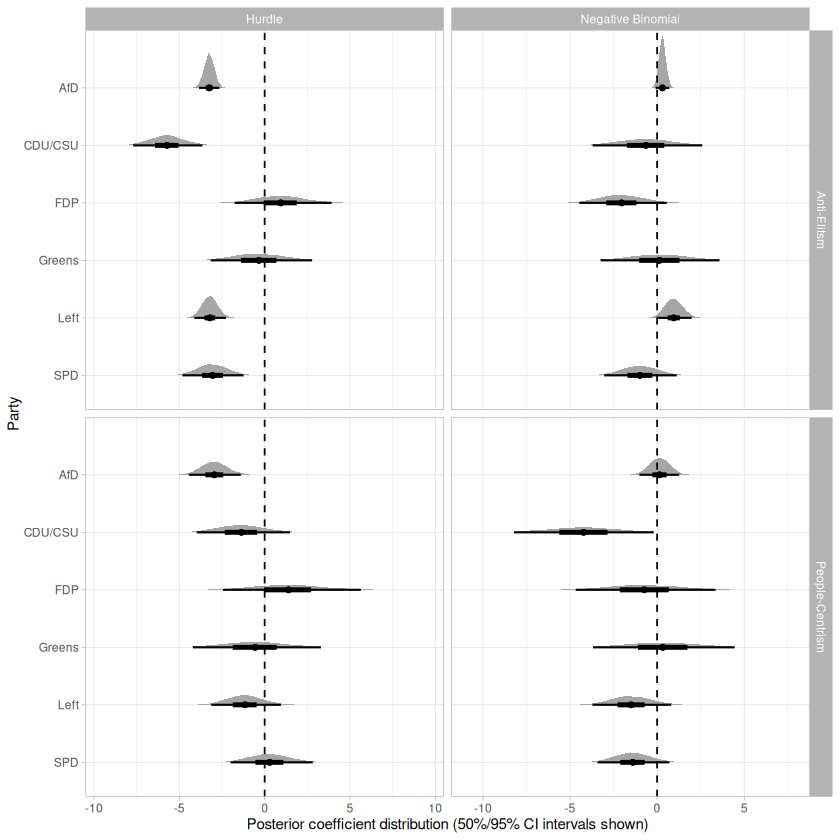

In [ ]:
lab_map <- c(
    b_hu_elite = "Anti-Elitism (Hurdle)",
    b_elite = "Anti-Elitism",
    b_hu_pplcentr = "People-Centrism (Hurdle)",
    b_pplcentr = "People-Centrism"
)

plot_df <- draws_all |>
    filter(.variable %in% names(lab_map)) |>
    mutate(
        term = factor(
            lab_map[.variable],
            levels = lab_map
        ),
        dimension = case_when(
            term %in% c("Anti-Elitism (Hurdle)", "People-Centrism (Hurdle)") ~ "Hurdle",
            term %in% c("Anti-Elitism", "People-Centrism") ~ "Negative Binomial"
        ),
        type = recode(type, "elite" = "Anti-Elitsm", "pplcentr" = "People-Centrism"),
        party = factor(party, levels = sort(unique(party), decreasing = TRUE)),
        party = recode(
            party,
            "spd" = "SPD",
            "left" = "Left",
            "greens" = "Greens",
            "fdp" = "FDP",
            "cdu_csu" = "CDU/CSU",
            "afd" = "AfD",
        )
    )


plot <- ggplot(plot_df, aes(x = .value, y = party)) +
    stat_halfeye(
        .width = c(.5, .95),
        point_interval = mean_qi,
        point_size = 0.9
    ) +
    geom_vline(xintercept = 0, linetype = "dashed") +
    theme_minimal(
        base_size = 9
    ) +
    facet_grid(
        rows = vars(type),
        cols = vars(dimension),
        scales = "free"
    ) +
    labs(
        x = "Posterior coefficient distribution (50%/95% CI intervals shown)",
        y = "Party"
    )

plot


In [ ]:
path <- here("reports", "figures", "hurdle_model_coefficients.jpg")
if (file.exists(path)) file.remove(path)
ggsave(
    path,
    plot,
    # device = cairo_ps,
    # fallback_resolution = 800,
    dpi = 900,
    width = 16,
    height = 9,
    units = "cm"
)


[1] TRUE